In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("prof_components_extracted")
firms_plot5 = ["EQNR.OL", "AKRBP.OL", "NHY.OL"]

# ---------- Load ALL firm CSVs into one panel ----------
MIN_YEAR = 2005
MAX_YEAR = 2024

rows = []
bad_files = []

for fp in sorted(DATA_DIR.glob("*.csv")):
    firm = fp.stem
    df = pd.read_csv(fp)

    if "Year" not in df.columns:
        bad_files.append(fp.name)
        continue

    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df = df.dropna(subset=["Year"]).copy()
    df["Year"] = df["Year"].astype(int)
    df = df[(df["Year"] >= MIN_YEAR) & (df["Year"] <= MAX_YEAR)].sort_values("Year")

    # fallback if needed
    if "firm" not in df.columns:
        df["firm"] = firm
    if "Ticker" not in df.columns:
        df["Ticker"] = firm

    rows.append(df)

if not rows:
    raise ValueError("No valid CSV files were loaded into panel.")

panel = pd.concat(rows, ignore_index=True)

panel["BE"] = pd.to_numeric(panel["BE"], errors="coerce")
panel["MIB"] = pd.to_numeric(panel["MIB"], errors="coerce")
panel["DENOM"] = panel["BE"] + panel["MIB"]

panel = panel.replace([np.inf, -np.inf], np.nan)
panel = panel.dropna(subset=["DENOM"]).copy()

# keep only positive denominators
panel = panel[panel["DENOM"] > 0].copy()

print(f"Panel after filter: {len(panel):,} rows, {panel['Ticker'].nunique():,} firms.")
print("Columns in panel:", panel.columns.tolist())

if bad_files:
    print("\nFiles skipped because Year column was missing:")
    for f in bad_files:
        print("-", f)

# Ensure PROF exists
if "PROF" not in panel.columns:
    raise ValueError("Column 'PROF' not found. Make sure you've computed PROF and saved it in each CSV.")

Panel after filter: 10,946 rows, 721 firms.
Columns in panel: ['Year', 'Ticker', 'CompanyName', 'Industry', 'Sector', 'REVT', 'COGS', 'XSGA_COMPONENTS', 'XRD', 'XINT', 'BE', 'MIB', 'PROF', 'firm', 'DENOM']


In [18]:
from IPython.display import HTML, display
# List unique industries in the current `panel` DataFrame (and counts)

if "Industry" not in panel.columns:
    raise ValueError("panel has no 'Industry' column. Rebuild panel from CSVs that include Industry/Sector.")

industry_counts = (
    panel.dropna(subset=["Industry"])
         .assign(Industry=lambda d: d["Industry"].astype(str).str.strip())
         .query("Industry != ''")
         .groupby("Industry")["firm"]
         .nunique()
         .sort_values(ascending=False)
         .reset_index()                          
         .rename(columns={"firm": "n_firms"})    
)

print(f"Number of unique industries: {len(industry_counts):,}")

html_table = industry_counts.to_html(index=False, escape=False)
html_scroll = f"""
<div style="max-height: 500px; overflow-y: auto; border: 1px solid #ccc;">
    {html_table}
</div>
"""

display(HTML(html_scroll))

Number of unique industries: 51


Industry,n_firms
"Machinery, Tools, Heavy Vehicles, Trains & Ships",64
Software & IT Services,56
Real Estate Operations,51
Banking Services,38
Professional & Commercial Services,31
Healthcare Equipment & Supplies,30
Construction & Engineering,28
Food & Tobacco,26
Biotechnology & Medical Research,25
Investment Banking & Investment Services,24


In [3]:
from IPython.display import HTML, display

financial_firms = (
    panel.loc[
        panel["Sector"].astype(str).str.strip().str.lower() == "financials",
        ["Ticker", "CompanyName", "Industry", "Sector"]
    ]
    .drop_duplicates()
    .copy()
)

# Extract exchange suffix from ticker, e.g. EQNR.OL -> OL
financial_firms["Exchange"] = financial_firms["Ticker"].astype(str).str.extract(r"\.([A-Za-z]+)$")[0]
financial_firms["Exchange"] = financial_firms["Exchange"].fillna("NO_SUFFIX")

# Sort by exchange first, then ticker
financial_firms = (
    financial_firms
    .sort_values(["Exchange", "Ticker"])
    .reset_index(drop=True)
)

print(f"Number of financial firms: {len(financial_firms)}")

html_table = financial_firms.to_html(index=False, escape=False)
html_scroll = f"""
<div style="max-height: 500px; overflow-y: auto; border: 1px solid #ccc;">
    {html_table}
</div>
"""

display(HTML(html_scroll))

Number of financial firms: 78


Ticker,CompanyName,Industry,Sector,Exchange
ALSYDB.CO,AL Sydbank A/S,Banking Services,Financials,CO
DABA.CO,Danske Andelskassers Bank A/S,Banking Services,Financials,CO
DANSKE.CO,Danske Bank A/S,Banking Services,Financials,CO
DJUR.CO,Djurslands Bank A/S,Banking Services,Financials,CO
FOBANK.CO,Foeroya Banki P/F,Banking Services,Financials,CO
FYNBK.CO,Fynske Bank A/S,Banking Services,Financials,CO
GRLA.CO,Groenlandsbanken A/S,Banking Services,Financials,CO
HVID.CO,Hvidbjerg Bank A/S,Banking Services,Financials,CO
JYSK.CO,Jyske Bank A/S,Banking Services,Financials,CO
KRE.CO,Kreditbanken A/S,Banking Services,Financials,CO


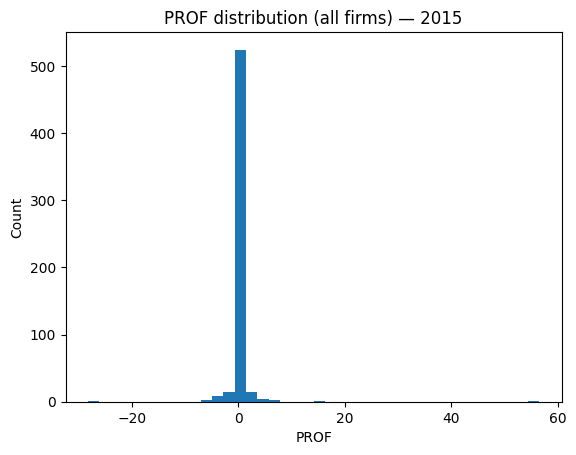

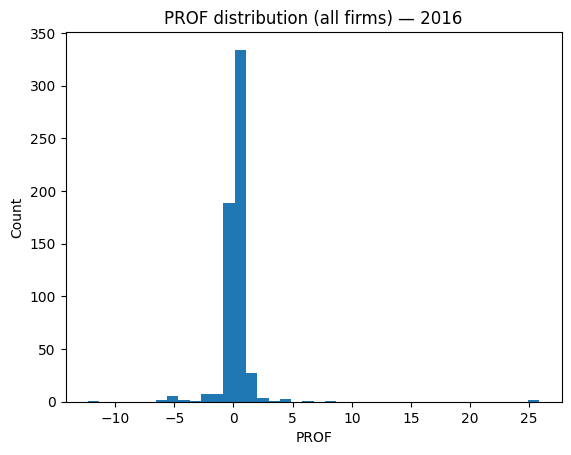

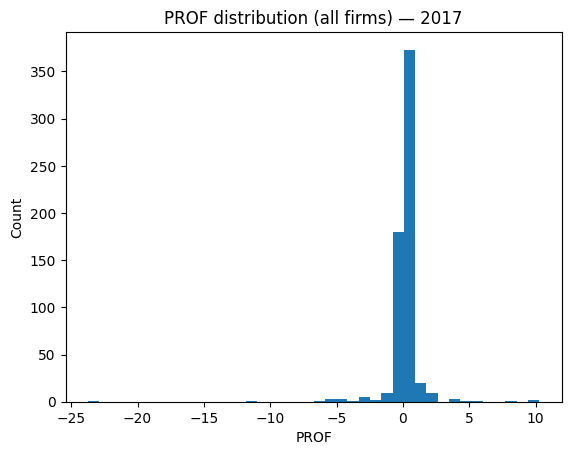

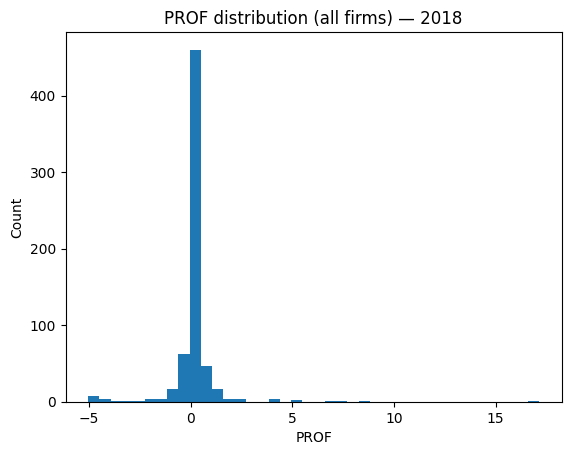

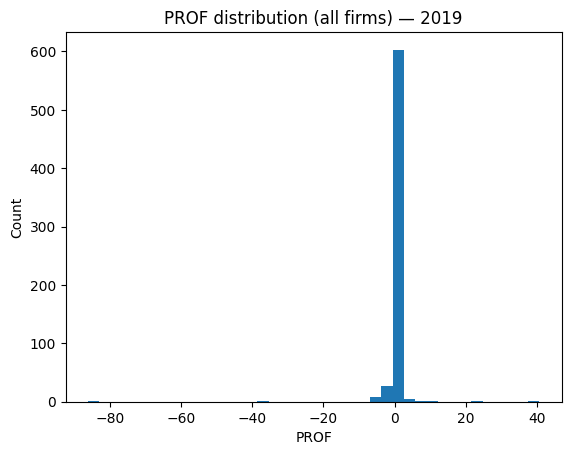

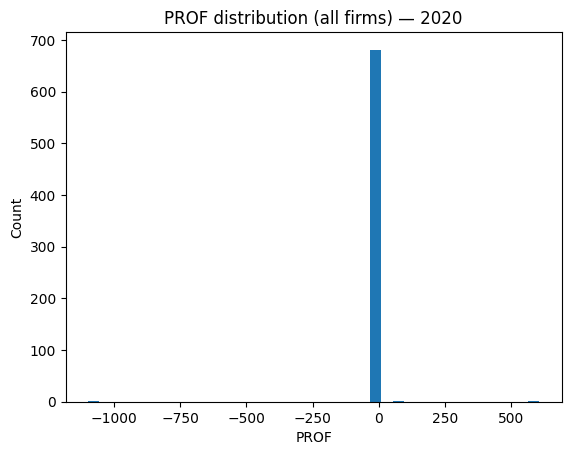

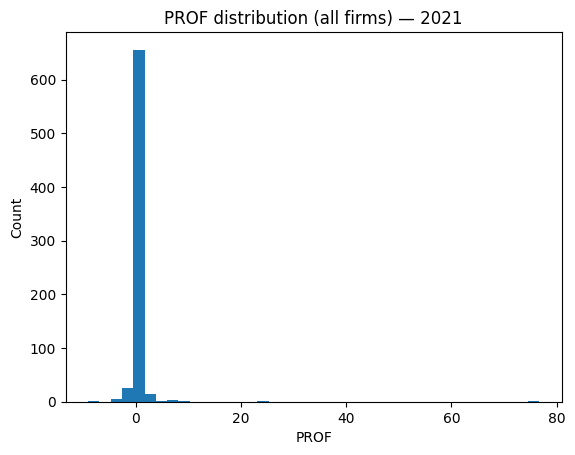

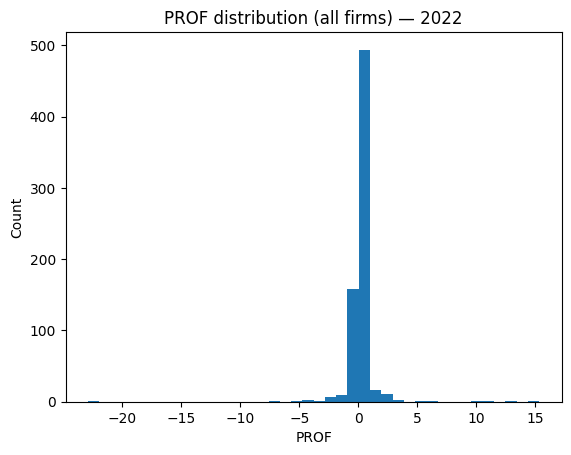

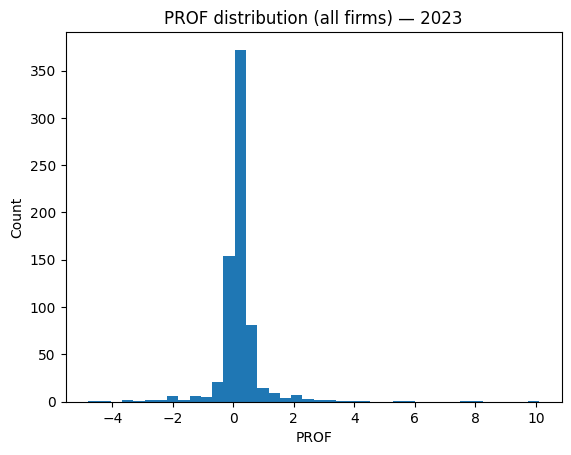

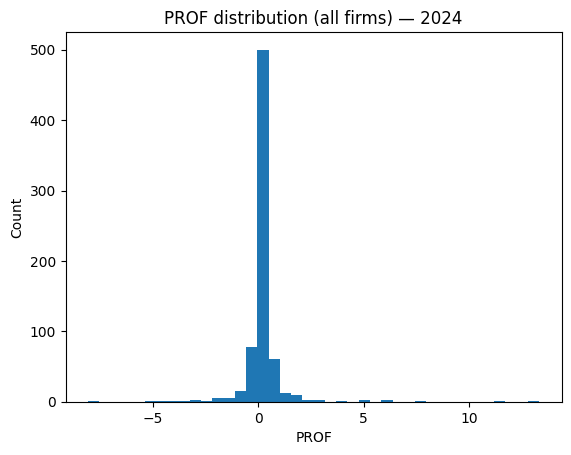

In [4]:

# ---------- Plot 1: PROF distribution each year (ALL firms) ----------
years = sorted(panel["Year"].unique())
years_to_plot = years[-10:] if len(years) > 10 else years  # last 10 years if many

for y in years_to_plot:
    vals = panel.loc[panel["Year"] == y, "PROF"].replace([np.inf, -np.inf], np.nan).dropna()
    plt.figure()
    plt.hist(vals, bins=40)
    plt.title(f"PROF distribution (all firms) — {y}")
    plt.xlabel("PROF")
    plt.ylabel("Count")
    plt.show()


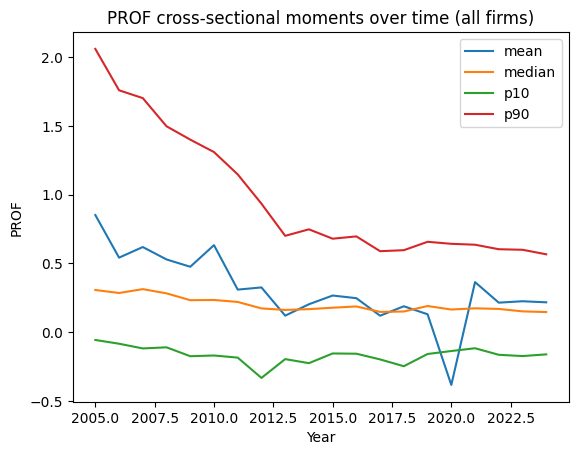

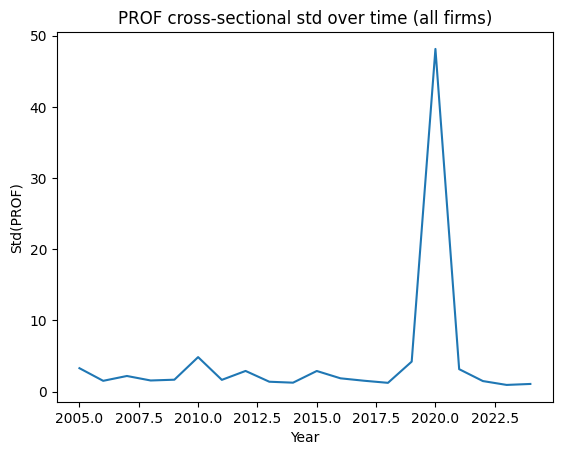

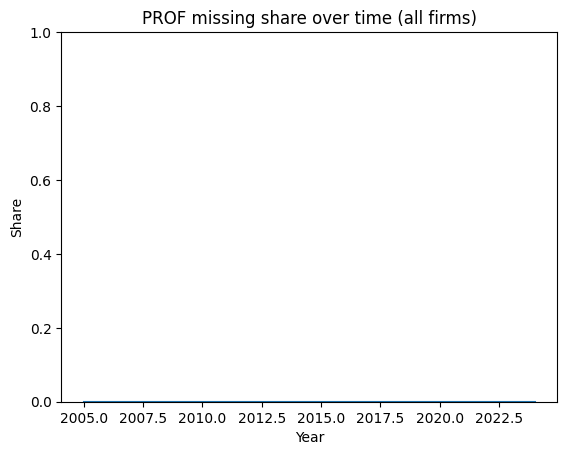

In [5]:

# ---------- Plot 2: Cross-sectional moments over time (ALL firms) ----------
def moments(g):
    s = g["PROF"].replace([np.inf, -np.inf], np.nan)
    return pd.Series({
        "mean": s.mean(),
        "median": s.median(),
        "p10": s.quantile(0.10),
        "p90": s.quantile(0.90),
        "std": s.std(),
        "n": s.notna().sum(),
        "nan_share": 1 - s.notna().mean(),
    })

mom = panel.groupby("Year").apply(moments).reset_index()

plt.figure()
plt.plot(mom["Year"], mom["mean"], label="mean")
plt.plot(mom["Year"], mom["median"], label="median")
plt.plot(mom["Year"], mom["p10"], label="p10")
plt.plot(mom["Year"], mom["p90"], label="p90")
plt.title("PROF cross-sectional moments over time (all firms)")
plt.xlabel("Year")
plt.ylabel("PROF")
plt.legend()
plt.show()

plt.figure()
plt.plot(mom["Year"], mom["std"])
plt.title("PROF cross-sectional std over time (all firms)")
plt.xlabel("Year")
plt.ylabel("Std(PROF)")
plt.show()

plt.figure()
plt.plot(mom["Year"], mom["nan_share"])
plt.title("PROF missing share over time (all firms)")
plt.xlabel("Year")
plt.ylabel("Share")
plt.ylim(0, 1)
plt.show()


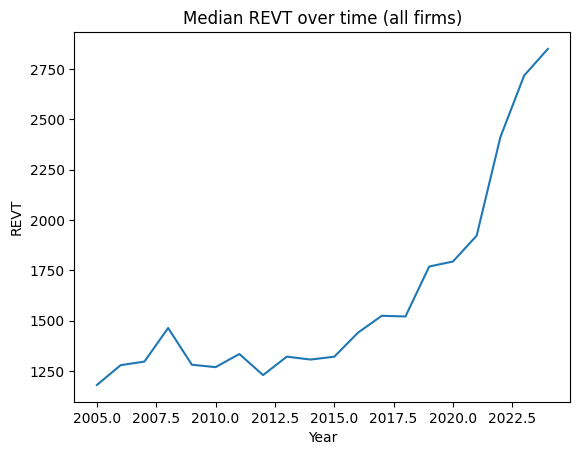

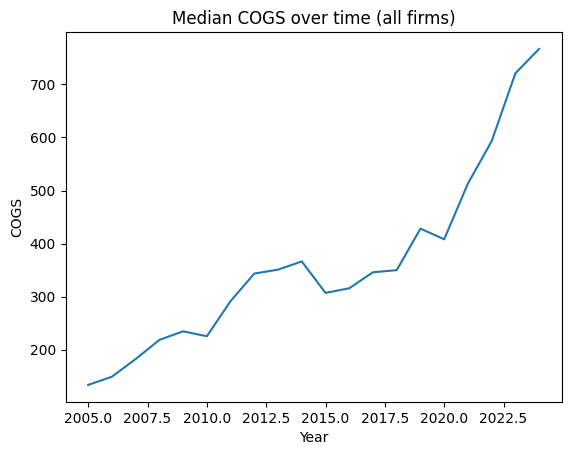

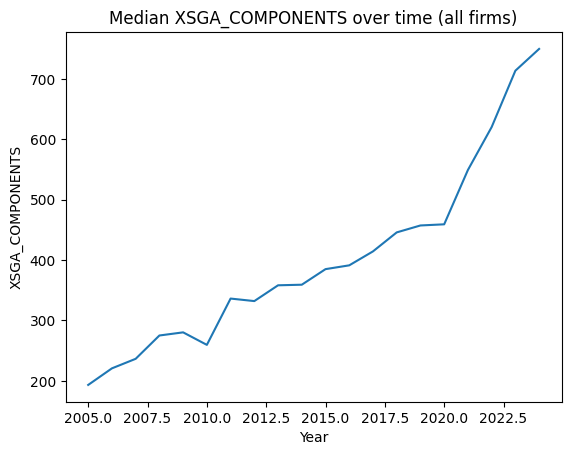

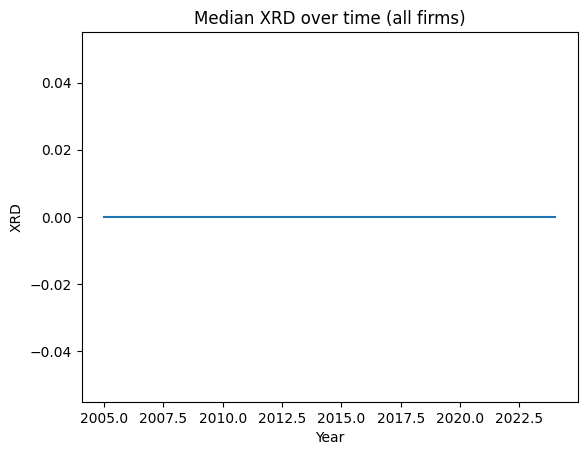

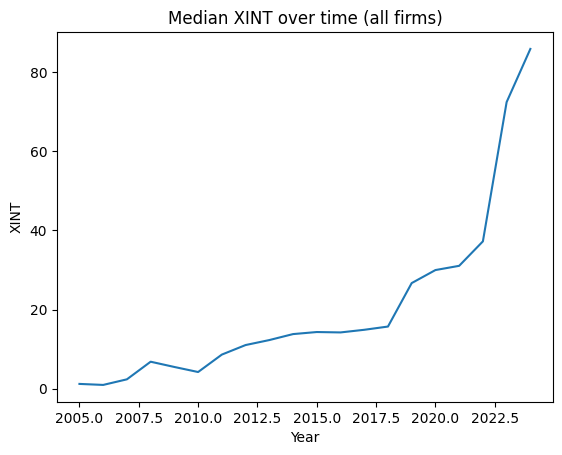

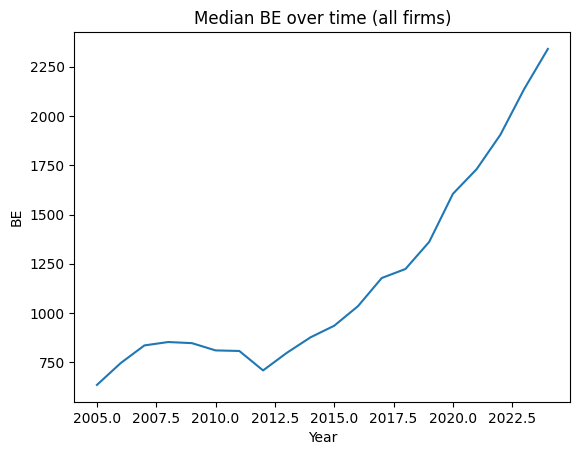

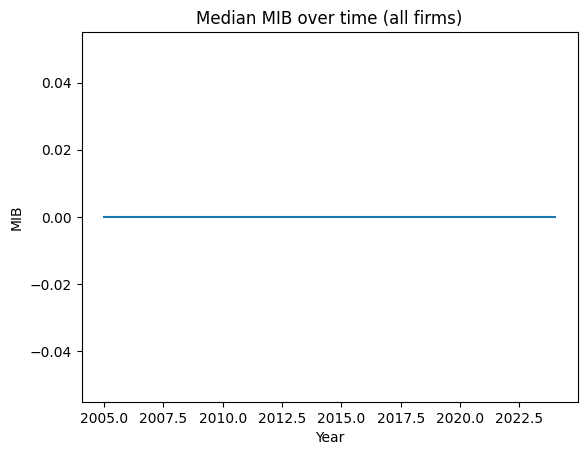

In [6]:

# ---------- Plot 3: Component diagnostics over time (ALL firms, medians) ----------
components = ["REVT", "COGS", "XSGA_COMPONENTS", "XRD", "XINT", "BE", "MIB"]
missing_components = [c for c in components if c not in panel.columns]
if missing_components:
    raise ValueError(f"Missing component columns in panel: {missing_components}")

comp_median = panel.groupby("Year")[components].median(numeric_only=True).reset_index()

for c in components:
    plt.figure()
    plt.plot(comp_median["Year"], comp_median[c])
    plt.title(f"Median {c} over time (all firms)")
    plt.xlabel("Year")
    plt.ylabel(c)
    plt.show()


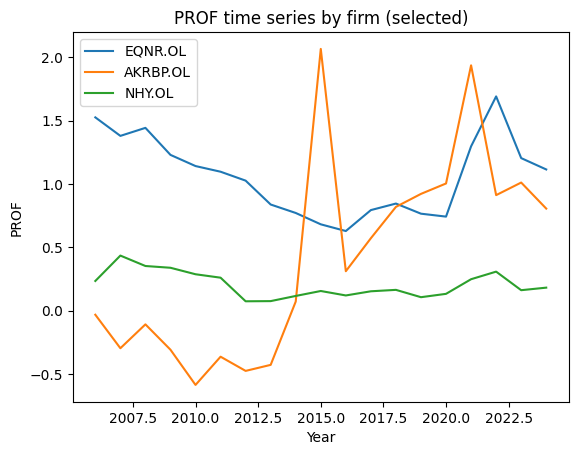

In [7]:

# ---------- Plot 5: Firm-level PROF time series (ONLY specified firms) ----------
plt.figure()
for f in firms_plot5:
    d = panel[panel["firm"] == f].sort_values("Year")
    if d.empty:
        print(f"[warn] No data found for {f}")
        continue
    plt.plot(d["Year"], d["PROF"], label=f)
plt.title("PROF time series by firm (selected)")
plt.xlabel("Year")
plt.ylabel("PROF")
plt.legend()
plt.show()

In [8]:
top5_one_row_per_year = (
    panel.assign(PROF=pd.to_numeric(panel["PROF"], errors="coerce"))
         .replace([np.inf, -np.inf], np.nan)
         .dropna(subset=["PROF"])
         .sort_values(["Year", "PROF"], ascending=[True, False])
         .groupby("Year", as_index=False)
         .head(5)
         .groupby("Year")
         .apply(lambda g: pd.Series({
             "top5_firms": ", ".join(g["firm"].tolist()),
             "top5_PROF": ", ".join([f"{x:.4f}" for x in g["PROF"].tolist()])
         }))
         .reset_index()
         .sort_values("Year")
         .reset_index(drop=True)
)

display(top5_one_row_per_year)

,Year,top5_firms,top5_PROF
0,2005,"AQ.ST, ATEA.OL, LOOMIS.ST, NAS.OL, CATb.ST","48.8671, 22.4555, 11.5817, 10.9941, 9.3137"
1,2006,"NAS.OL, CATb.ST, BILIa.ST, PROFb.ST, AKAST.OL","10.7473, 10.7356, 7.0427, 6.2680, 6.1823"
2,2007,"ARCHA.OL, CATb.ST, BILIa.ST, AKAST.OL, NCCb.ST","29.5115, 13.6597, 9.3255, 7.9466, 7.9135"
3,2008,"MOWI.OL, BILIa.ST, ARCHA.OL, NCCb.ST, IOX.OL","11.9971, 9.7008, 8.9575, 8.3611, 7.7158"
4,2009,"NELLY.ST, WALLb.ST, BILIa.ST, SOSI1.HE, NCCb.ST","17.5138, 10.9412, 8.5364, 8.0000, 7.2137"
5,2010,"AFG.OL, PREVb.ST, AXFO.ST, WALLb.ST, BILIa.ST","86.6818, 39.3158, 9.9455, 9.1932, 8.0149"
6,2011,"PREVb.ST, BILIa.ST, AXFO.ST, VERK.HE, NAS.OL","20.5427, 9.8674, 8.2893, 5.6176, 4.3306"
7,2012,"BWLPG.OL, TRACb.ST, VERK.HE, LEHTO.HE, AFG.OL","52.9398, 23.5355, 7.6974, 7.1407, 6.8339"
8,2013,"AFG.OL, ATEA.OL, ORIOLA.HE, NAS.OL, VERK.HE","9.0473, 4.9272, 4.5771, 4.2561, 4.1347"
9,2014,"ORIOLA.HE, CONSTI.HE, PREVb.ST, NAS.OL, AFG.OL","11.1796, 7.9214, 7.7214, 6.8540, 5.6912"


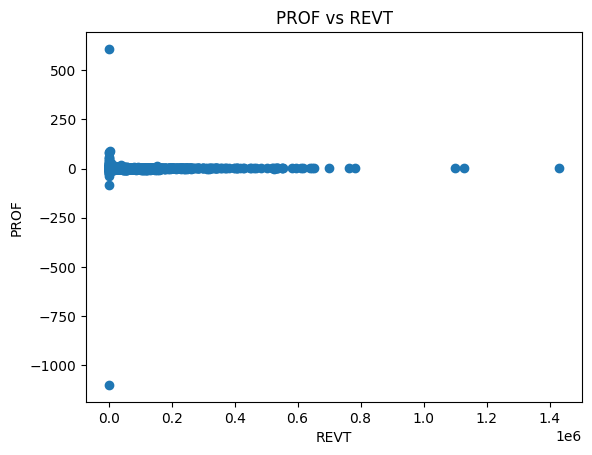

In [9]:
# Scatterplot: PROF (y) vs REVT (x), using existing `panel`
x = pd.to_numeric(panel["REVT"], errors="coerce")
y = pd.to_numeric(panel["PROF"], errors="coerce")

mask = np.isfinite(x) & np.isfinite(y)
plt.figure()
plt.scatter(x[mask], y[mask])
plt.title("PROF vs REVT")
plt.xlabel("REVT")
plt.ylabel("PROF")
plt.show()

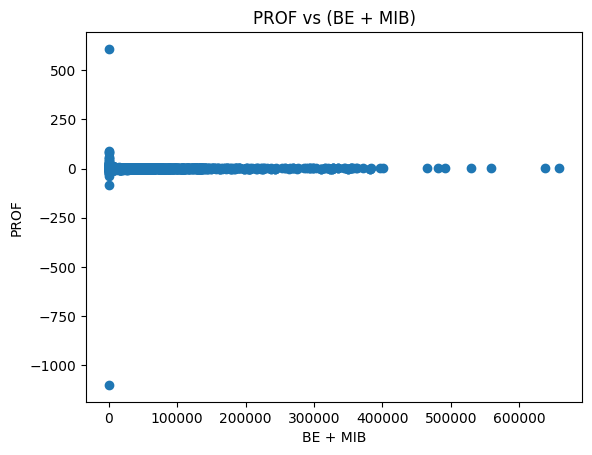

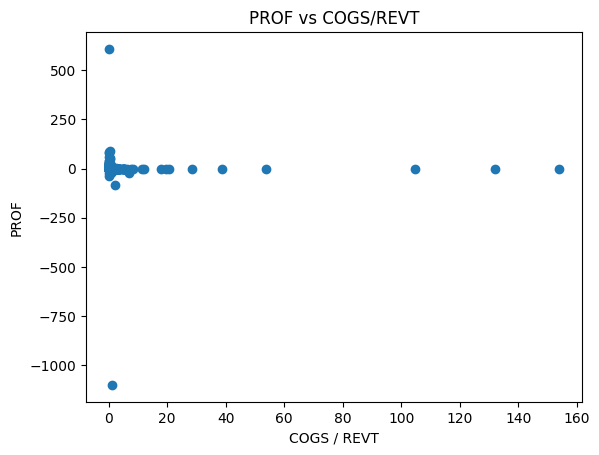

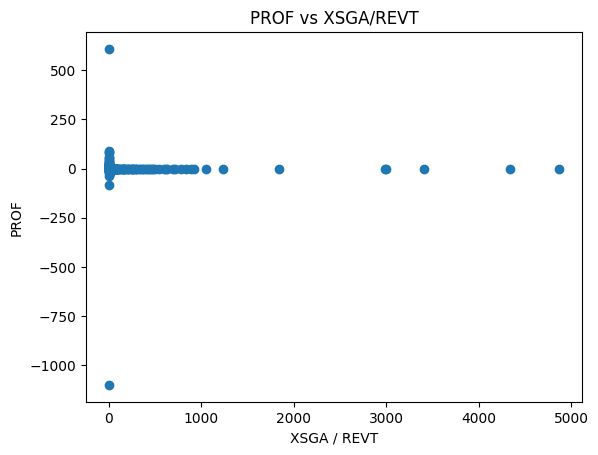

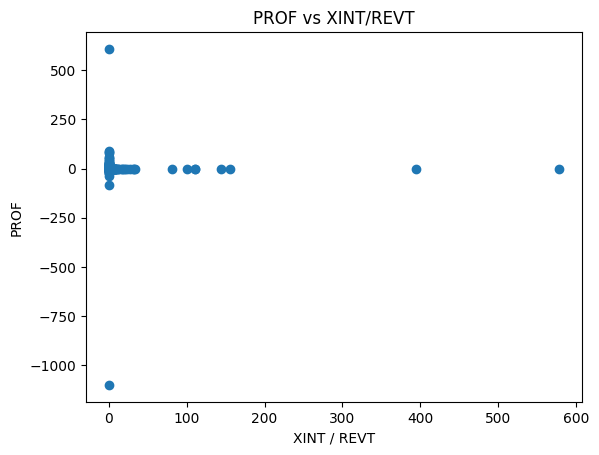

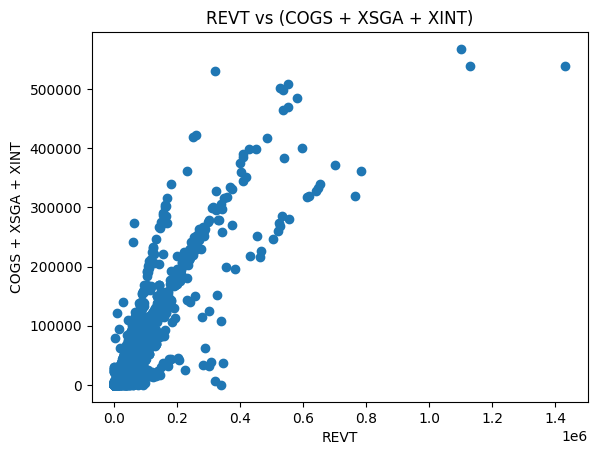

In [10]:
def scatter(x, y, title, xlabel, ylabel):
    x = pd.to_numeric(x, errors="coerce")
    y = pd.to_numeric(y, errors="coerce")
    mask = np.isfinite(x) & np.isfinite(y)
    plt.figure()
    plt.scatter(x[mask], y[mask])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

# 1) PROF vs denominator
denom = pd.to_numeric(panel["BE"], errors="coerce") + pd.to_numeric(panel["MIB"], errors="coerce")
scatter(denom, panel["PROF"], "PROF vs (BE + MIB)", "BE + MIB", "PROF")

# 2) PROF vs COGS/REVT (gross margin proxy)
ratio_cogs = pd.to_numeric(panel["COGS"], errors="coerce") / pd.to_numeric(panel["REVT"], errors="coerce")
scatter(ratio_cogs, panel["PROF"], "PROF vs COGS/REVT", "COGS / REVT", "PROF")

# 3) PROF vs XSGA/REVT
ratio_xsga = pd.to_numeric(panel["XSGA_COMPONENTS"], errors="coerce") / pd.to_numeric(panel["REVT"], errors="coerce")
scatter(ratio_xsga, panel["PROF"], "PROF vs XSGA/REVT", "XSGA / REVT", "PROF")

# 4) PROF vs XINT/REVT
ratio_xint = pd.to_numeric(panel["XINT"], errors="coerce") / pd.to_numeric(panel["REVT"], errors="coerce")
scatter(ratio_xint, panel["PROF"], "PROF vs XINT/REVT", "XINT / REVT", "PROF")

# 5) REVT vs total costs (COGS + XSGA + XINT)
total_costs = (
    pd.to_numeric(panel["COGS"], errors="coerce")
    + pd.to_numeric(panel["XSGA_COMPONENTS"], errors="coerce")
    + pd.to_numeric(panel["XINT"], errors="coerce")
)
scatter(panel["REVT"], total_costs, "REVT vs (COGS + XSGA + XINT)", "REVT", "COGS + XSGA + XINT")

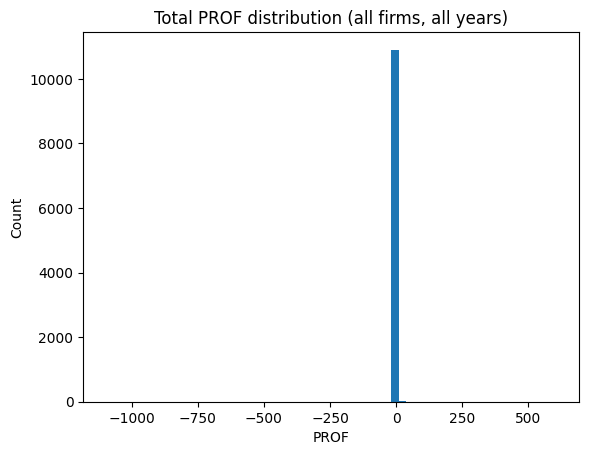

In [11]:
# Total distribution of PROF (all firms + all years currently in `panel`)
vals = pd.to_numeric(panel["PROF"], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()

plt.figure()
plt.hist(vals, bins=60)
plt.title("Total PROF distribution (all firms, all years)")
plt.xlabel("PROF")
plt.ylabel("Count")
plt.show()

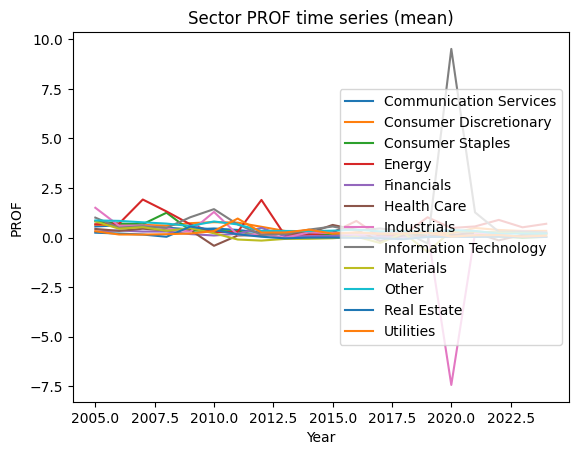

In [12]:
# Clean PROF
df = panel.copy()
df["PROF"] = pd.to_numeric(df["PROF"], errors="coerce").replace([np.inf, -np.inf], np.nan)

# Sector-year mean PROF (you can switch to median if you prefer)
ind_ts = (
    df.dropna(subset=["Sector", "PROF"])
      .groupby(["Year", "Sector"])["PROF"]
      .mean()
      .reset_index()
)

# Pivot to wide for plotting
wide = ind_ts.pivot(index="Year", columns="Sector", values="PROF").sort_index()

plt.figure()
for col in wide.columns:
    plt.plot(wide.index, wide[col], label=col)

plt.title("Sector PROF time series (mean)")
plt.xlabel("Year")
plt.ylabel("PROF")
plt.legend()
plt.show()

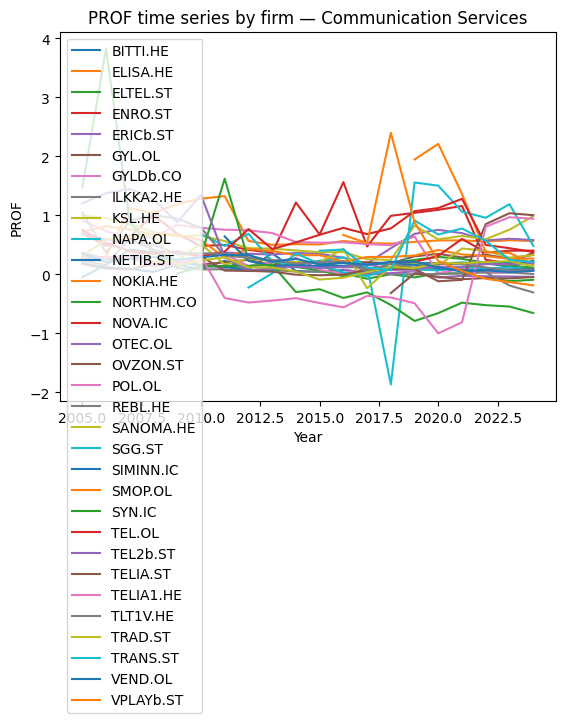

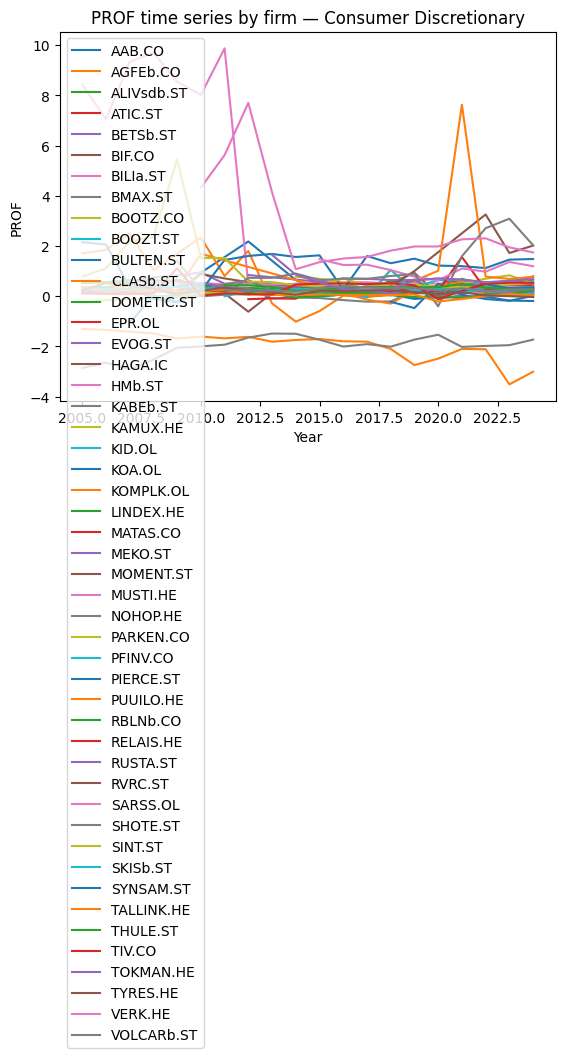

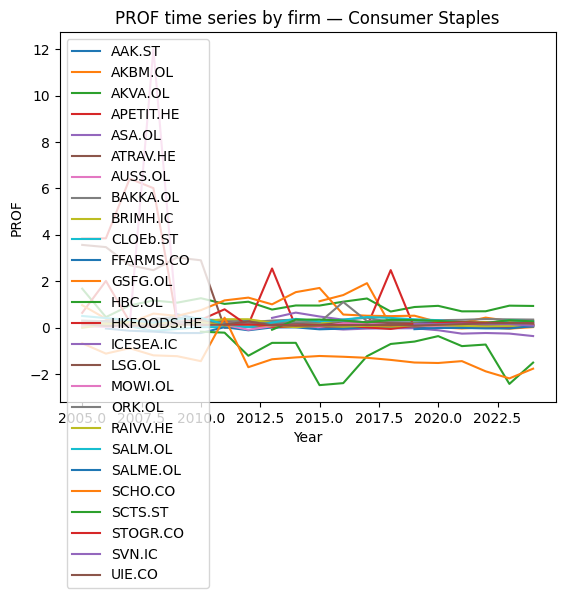

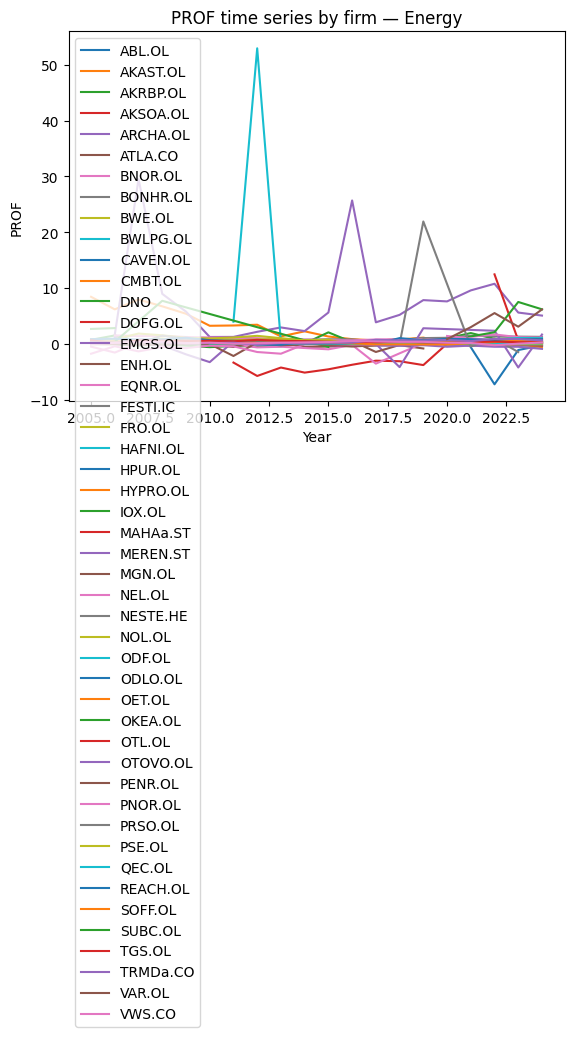

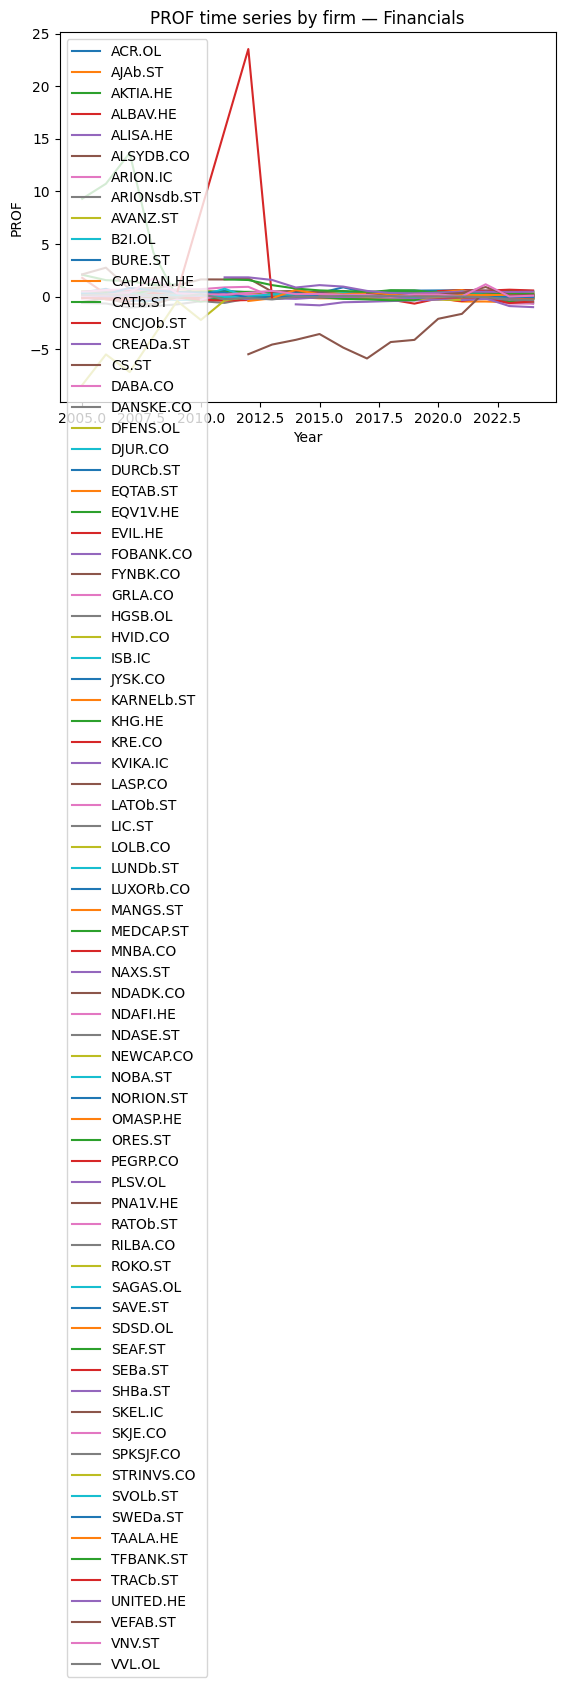

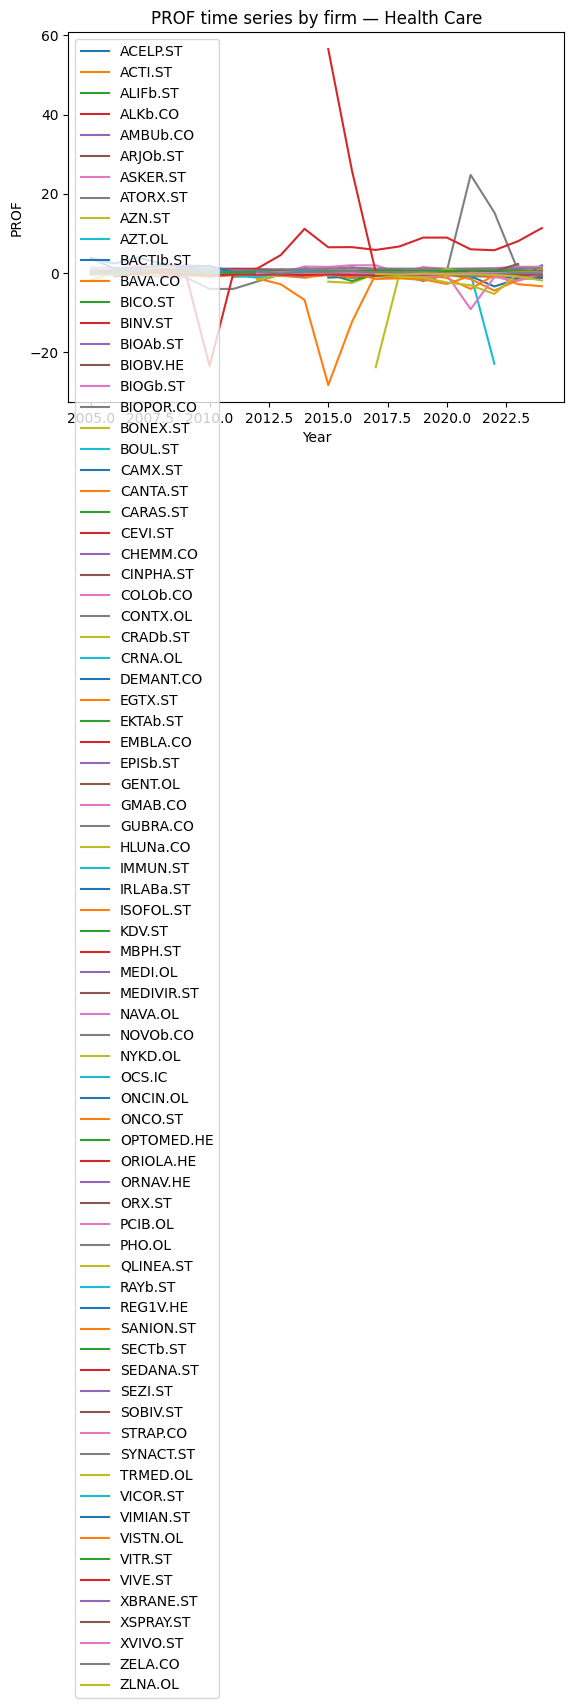

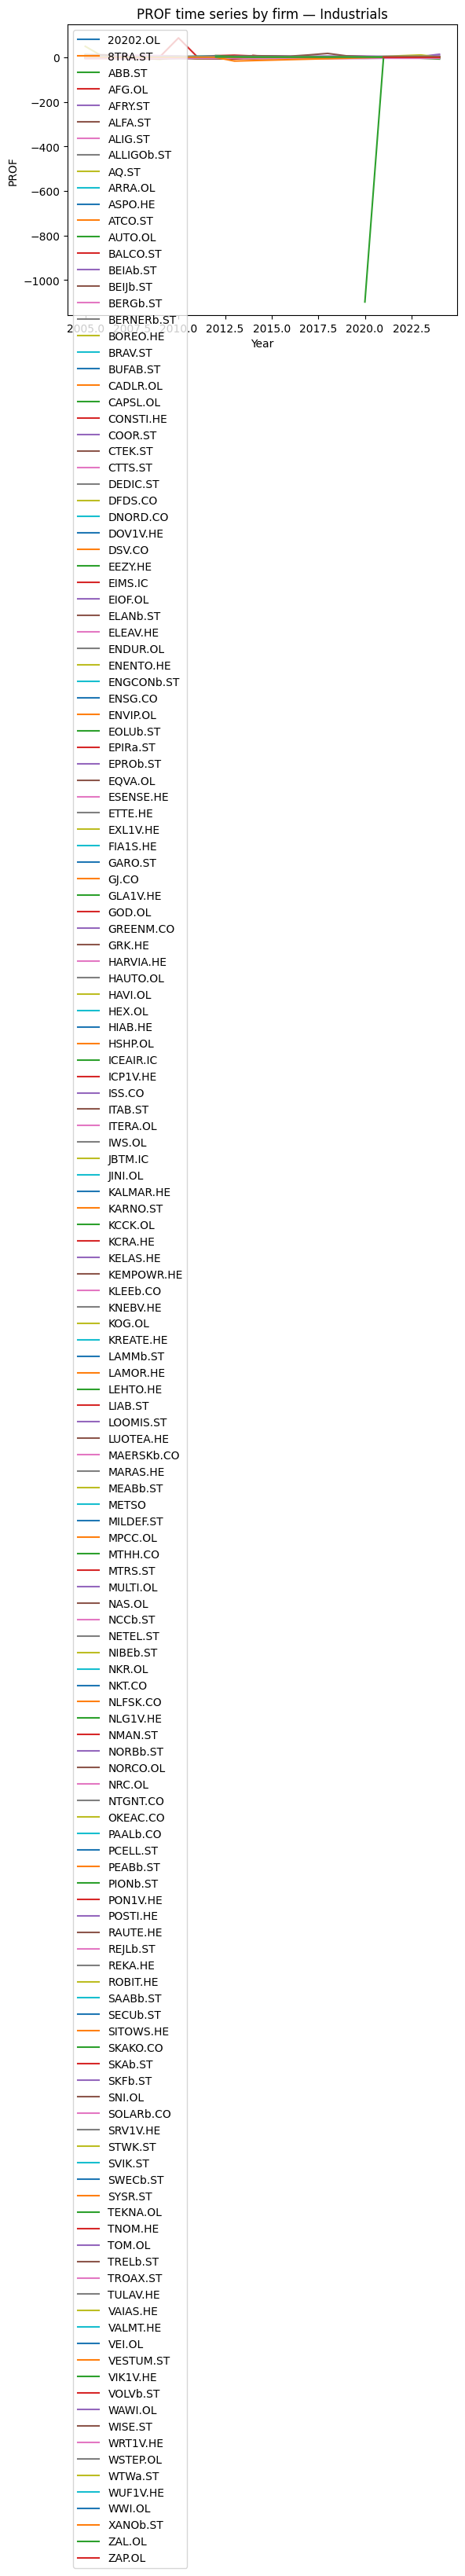

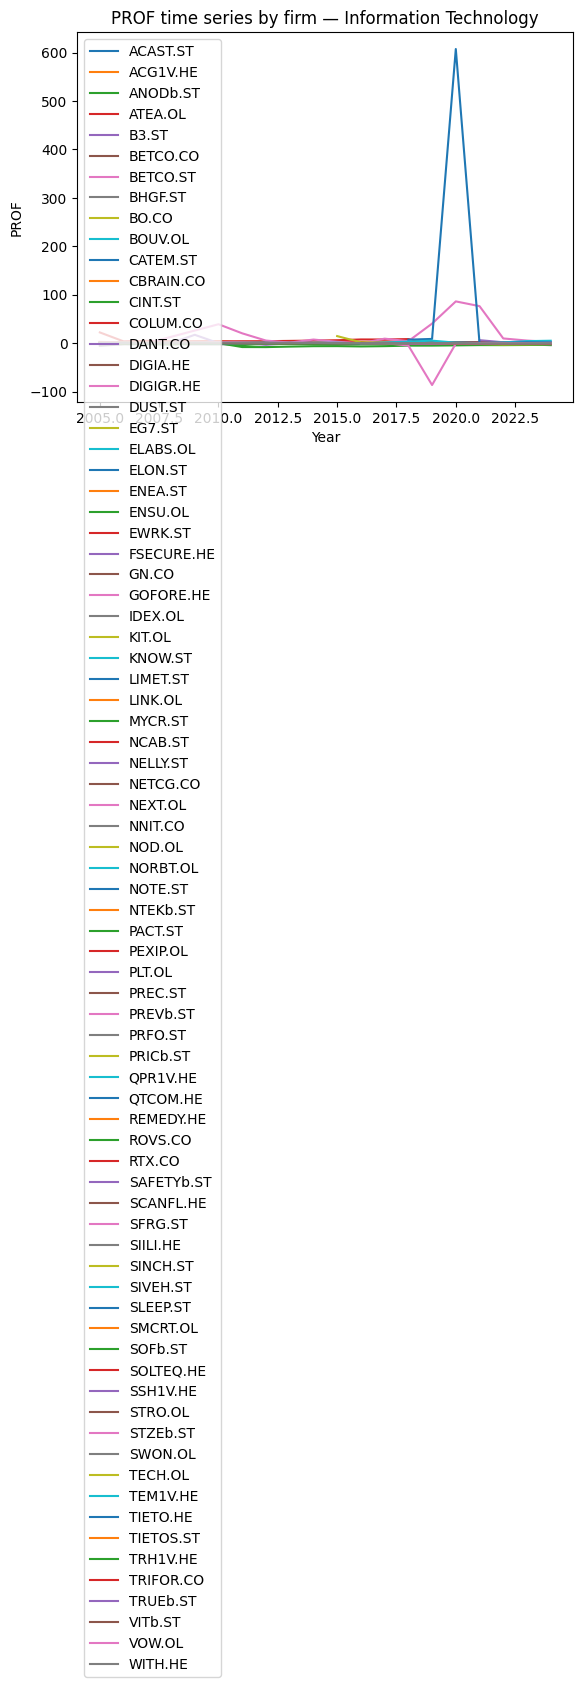

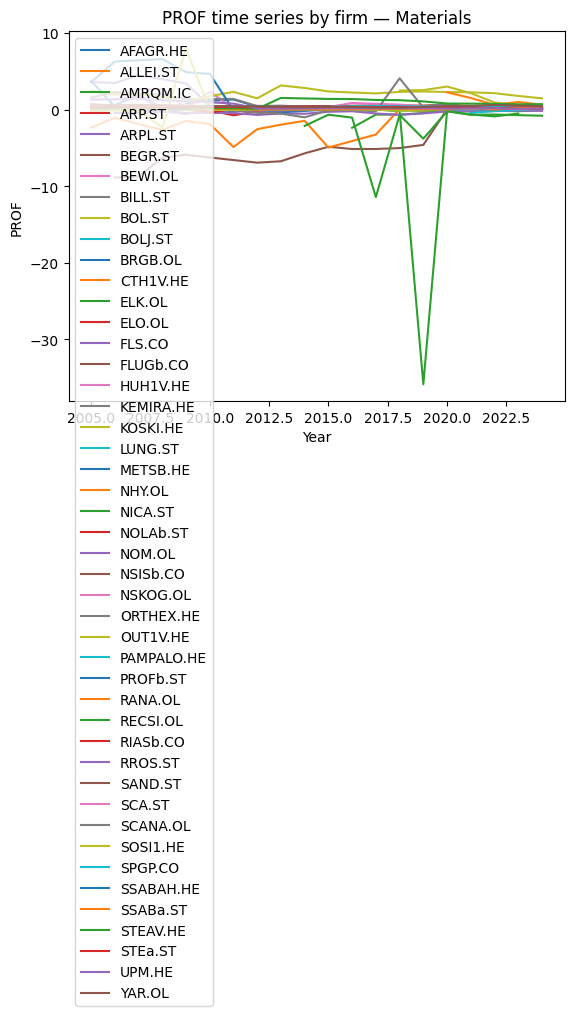

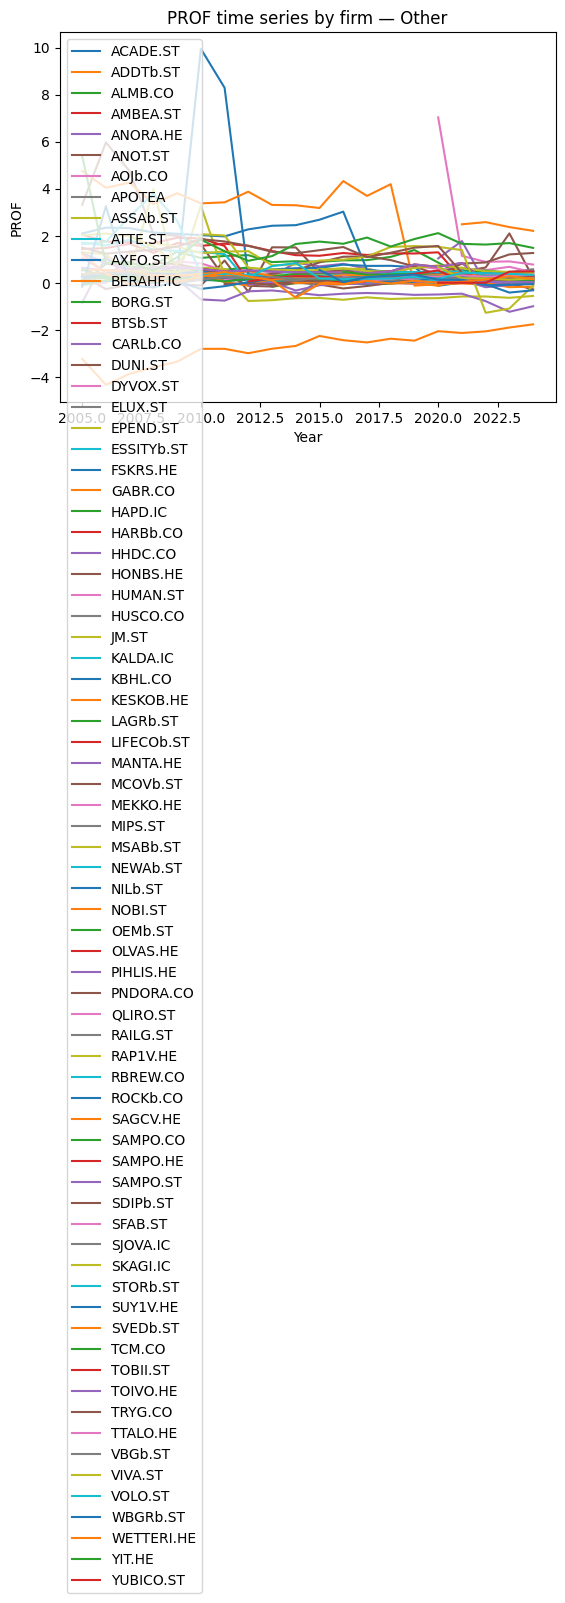

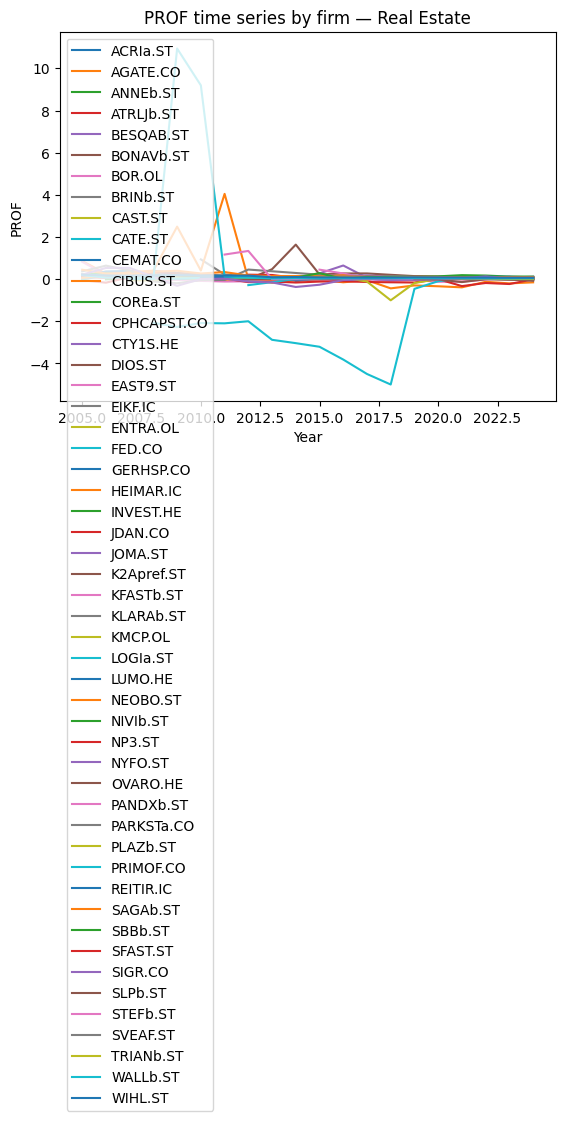

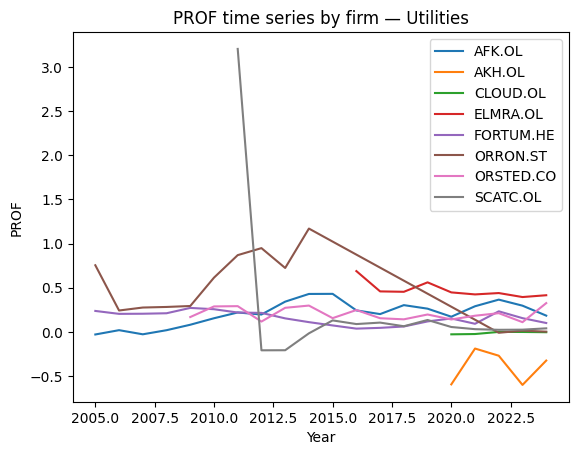

In [13]:
# Assumes `panel` exists and has columns: Year, firm, Industry, PROF
df = panel.copy()
df["PROF"] = pd.to_numeric(df["PROF"], errors="coerce").replace([np.inf, -np.inf], np.nan)

# Optional: pick a subset of industries to avoid insanely crowded plots
industries = sorted(df["Sector"].dropna().unique())

for ind in industries:
    sub = df[df["Sector"] == ind].dropna(subset=["PROF"]).copy()
    if sub.empty:
        continue

    plt.figure()
    for firm, g in sub.groupby("firm"):
        g = g.sort_values("Year")
        plt.plot(g["Year"], g["PROF"], label=firm)

    plt.title(f"PROF time series by firm — {ind}")
    plt.xlabel("Year")
    plt.ylabel("PROF")
    plt.legend()
    plt.show()

In [14]:
# All observations where |PROF| > 5 (using existing `panel`)
outliers = (
    panel.assign(PROF=pd.to_numeric(panel["PROF"], errors="coerce"))
         .replace([np.inf, -np.inf], np.nan)
         .dropna(subset=["PROF"])
)Fet

outliers = outliers[outliers["PROF"].abs() > 7].copy()

# Show the key columns (add/remove as you like)
cols = [c for c in ["Year", "firm", "CompanyName", "Industry", "Sector", "PROF",
                    "REVT", "COGS", "XSGA_COMPONENTS", "XRD", "XINT", "BE", "MIB"] if c in outliers.columns]

outliers = outliers[cols].sort_values(["Year", "PROF"], ascending=[True, False]).reset_index(drop=True)

print(f"Found {len(outliers)} observations with |PROF| > 7")
display(outliers)

SyntaxError: invalid syntax (1871448865.py, line 6)

In [ ]:
# Top 5 firms by average PROF over the last 5 years in `panel`
df = panel.copy()
df["PROF"] = pd.to_numeric(df["PROF"], errors="coerce").replace([np.inf, -np.inf], np.nan)

# Determine last 5 years available (based on panel years)
years = sorted(df["Year"].dropna().unique())
last5_years = years[-5:]

top5_last5 = (
    df[df["Year"].isin(last5_years)]
      .dropna(subset=["PROF"])
      .groupby("firm", as_index=False)
      .agg(avg_PROF=("PROF", "mean"),
           n_obs=("PROF", "count"),
           CompanyName=("CompanyName", "first"),
           Industry=("Industry", "first"),
           Sector=("Sector", "first"))
      .sort_values("avg_PROF", ascending=False)
      .head(5)
      .reset_index(drop=True)
)

print("Last 5 years used:", last5_years)
display(top5_last5)

Last 5 years used: [2020, 2021, 2022, 2023, 2024]


,firm,avg_PROF,n_obs,CompanyName,Industry,Sector
0,CONTX.OL,8.335314,5,ContextVision AB,Healthcare Equipment & Supplies,Health Care
1,MULTI.OL,4.004683,5,Multiconsult ASA,Construction & Engineering,Industrials
2,VAR.OL,3.753548,5,Var Energi ASA,Oil & Gas,Energy
3,TOM.OL,3.471495,5,Tomra Systems ASA,"Machinery, Tools, Heavy Vehicles, Trains & Ships",Industrials
4,HAVI.OL,3.105404,4,Havila Shipping ASA,Freight & Logistics Services,Industrials
